In [1]:
# Import libraries
import numpy as np
import pandas as pd
import torch
import torch.distributions as dist
from scipy.stats import gamma
from concurrent.futures import ProcessPoolExecutor
import functools
from sklearn.linear_model import Ridge
import pickle
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

Sample from posterior

In [2]:
# FFBS sampler
def sample_trajectory(ES, VS, Cov):
    T = len(ES)
    S = np.zeros(T)

    S[T-1] = np.random.normal(ES[T-1], np.sqrt(VS[T-1]))

    for t in range(T-2, -1, -1):
        J = Cov[t+1] / VS[t+1]
        mean = ES[t] + J * (S[t+1] - ES[t+1])
        var  = VS[t] - J * Cov[t+1]
        var = max(var, 1e-8)

        S[t] = np.random.normal(mean, np.sqrt(var))

    return S

# helper functions to compute various quantities
def compute_empirical_growth(df_c):
    df_c = df_c.sort_values('date').copy()
    df_c['emp_growth'] = np.exp(df_c['log_cases'].diff())
    return df_c

def get_block_covariates(country, time_block, block_cov):
    key = (country, time_block)
    if key in block_cov.index:
        return (float(block_cov.loc[key, 'stringency_lag']),
                float(block_cov.loc[key, 'log_vac_lag']))
    return 0.0, 0.0

def compute_model_R(df_c, beta, theta_c, block_cov, sigma2=0.03):
    mu = []

    U_c1 = float(df_c['pc1'].iloc[0])
    U_c2 = float(df_c['pc2'].iloc[0])

    for _, row in df_c.iterrows():
        V_str, V_vac = get_block_covariates(row['country'], row['time_block'], block_cov)

        val = (beta[0]
               + beta[1]*U_c1
               + beta[2]*U_c2
               + beta[3]*V_str
               + beta[4]*V_vac
               + theta_c)

        # exponentiate
        if sigma2 is not None:
            val = np.exp(val + 0.5 * sigma2)  # corrected mean
        else:
            val = np.exp(val)

        mu.append(val)

    return np.array(mu)

# generate plot
def plot_growth(country, df, results, beta, theta, block_cov, sigma2=0.03, n_samples=100):
    df_c = df[df['country'] == country].copy()
    df_c = compute_empirical_growth(df_c)

    res = results[country]
    ES  = res['ES']
    ES2 = res['ES2']
    ESS = res['ESS']

    VS = ES2 - ES**2

    Cov = np.zeros_like(ES)
    Cov[1:] = ESS - ES[1:] * ES[:-1]
    dates = res['dates']

    # align df with KF output
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # posterior samples
    samples = []
    for _ in range(n_samples):
        S = sample_trajectory(ES, VS, Cov)
        growth = np.exp(np.diff(S))
        samples.append(growth)

    samples = np.array(samples)

    # posterior mean
    post_mean = samples.mean(axis=0)

    lower = np.percentile(samples, 10, axis=0)
    upper = np.percentile(samples, 90, axis=0)

    # empirical
    emp = df_c['emp_growth'].values[1:]

    # model-implied
    model_R = compute_model_R(df_c, beta, theta[country], block_cov)
    model_R = model_R[1:]  # align with diff

    dates_plot = df_c['date'].values[1:]

    # plot
    plt.figure(figsize=(12,6))

    # posterior mean (black)
    plt.fill_between(dates_plot, lower, upper,
                    color='gray', alpha=0.3,
                    label='Posterior 10–90%')

    # posterior mean
    plt.plot(dates_plot, post_mean,
            color='black', lw=2,
            label='Posterior mean')

    # empirical (blue line)
    plt.plot(dates_plot, emp, color='blue', lw=1.5, alpha=0.7, label='Empirical')

    # model implied (red)
    plt.step(dates_plot, model_R, where='mid', color='red', lw=2,
             label='Model-implied')

    plt.title(f'Growth comparison: {country}')
    plt.ylabel('Growth factor')
    plt.xlabel('Date')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [3]:

if __name__ == '__main__':
    # Load data
    freq = "seasonal" # TODO: change
    with open(f'../data/posterior_results_{freq}.pkl', 'rb') as f:
        data = pickle.load(f)

    results = data['results']
    countries = list(results.keys())

    n_samples = 300
    records = []

    # Sample posterior for each country
    for country in countries:
        ES  = results[country]['ES']
        ES2 = results[country]['ES2']
        ESS = results[country]['ESS']

        VS = ES2 - ES**2

        Cov = np.zeros_like(ES)
        Cov[1:] = ESS - ES[1:] * ES[:-1]
        dates = results[country]['dates']

        T = len(ES)

        R_samples = np.zeros((n_samples, T-1))

        for m in range(n_samples):
            S = sample_trajectory(ES, VS, Cov)
            R_samples[m, :] = np.exp(S[1:] - S[:-1])

        # Summary
        R_mean = R_samples.mean(axis=0)
        R_low  = np.percentile(R_samples, 5, axis=0)
        R_high = np.percentile(R_samples, 95, axis=0)
        R_prob = (R_samples > 1).mean(axis=0)

        for t in range(T-1):
            records.append({
                'country': country,
                'date': dates[t+1],
                'R_mean': R_mean[t],
                'R_low': R_low[t],
                'R_high': R_high[t],
                'P_R_gt_1': R_prob[t]
            })

    df_out = pd.DataFrame(records)
    df_out.to_csv(f'../data/R_posterior_summary_{freq}.csv', index=False)

    print("Saved R_posterior_summary.csv")

Saved R_posterior_summary.csv


Look into a specific country

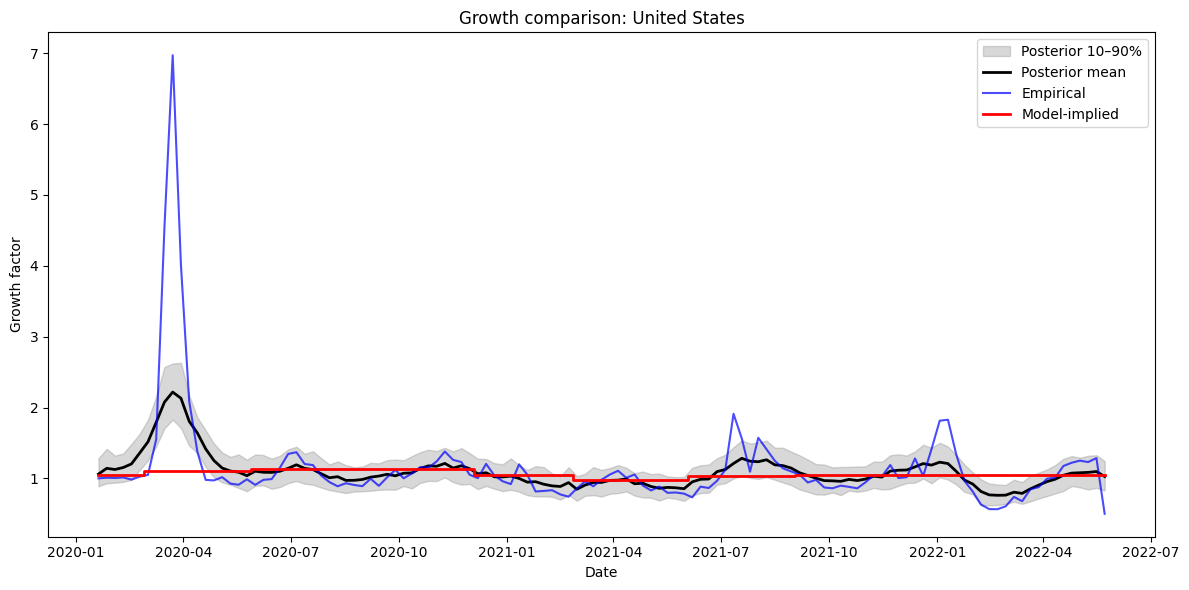

In [4]:
if __name__ == '__main__':

    # Load data
    df = pd.read_csv(f'../data/covid_{freq}.csv', parse_dates=['date'])
    df = df.sort_values(['country', 'date']).reset_index(drop=True)
    block_cov = pd.read_csv(f'../data/block_cov_{freq}.csv')
    block_cov = block_cov.set_index(['country', 'time_block'])
    
    # Load posterior
    with open(f'../data/posterior_results_{freq}.pkl', 'rb') as f:
        saved = pickle.load(f)

    results = saved['results']
    beta    = saved['beta']
    theta   = saved['theta']
    tau2    = saved['tau2']

    plot_growth(
        country='United States',
        df=df,
        results=results,
        beta=beta,
        theta=theta,
        block_cov=block_cov,
        n_samples=100
    )

Autocorrelation across residuals

In [5]:
def compute_residuals(country, df, results):
    df_c = df[df['country'] == country].sort_values('date').reset_index(drop=True)

    ES = results[country]['ES']  # posterior mean of Z_t
    assert len(ES) == len(df_c)
    residual = df_c['log_cases'].values - ES

    return df_c['date'].values, residual

def plot_residual_acf(country, df, results, nlags=10):
    dates, residual = compute_residuals(country, df, results)

    acf_vals = acf(residual, nlags=nlags)

    n = len(residual)
    ci = 1.96 / np.sqrt(n)

    plt.figure(figsize=(6,4))

    plt.stem(range(len(acf_vals)), acf_vals)   # ← fixed line

    plt.axhline(0, color='black')
    plt.axhline(ci, linestyle='--', color='red')
    plt.axhline(-ci, linestyle='--', color='red')

    plt.title(f'Residual ACF ({country})')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.show()

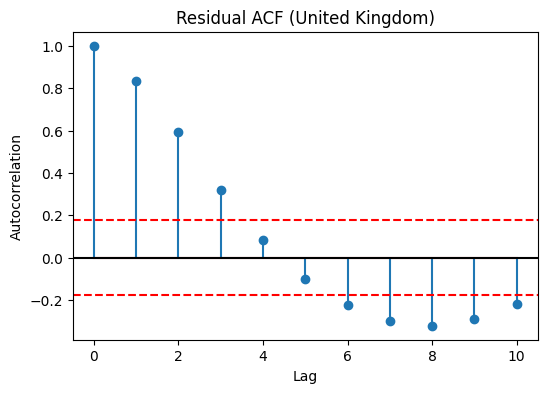

In [6]:
plot_residual_acf(
    country='United Kingdom',
    df=df,
    results=results,
    nlags=10
)